Using device: cuda
Copycat Classes: ['happy', 'neutral', 'sad']
Epoch 1: Train=96.20% | Test=49.67%
Epoch 2: Train=98.37% | Test=54.89%
Epoch 3: Train=98.89% | Test=52.19%
Epoch 4: Train=99.11% | Test=55.67%
Epoch 5: Train=99.32% | Test=54.68%
Epoch 6: Train=99.32% | Test=59.05%
Epoch 7: Train=99.50% | Test=59.76%
Epoch 8: Train=99.60% | Test=59.57%
Epoch 9: Train=99.58% | Test=54.11%
Epoch 10: Train=99.68% | Test=62.22%
Epoch 11: Train=99.72% | Test=55.31%
Epoch 12: Train=99.72% | Test=62.76%
Epoch 13: Train=99.82% | Test=52.87%
Epoch 14: Train=99.80% | Test=55.55%
Epoch 15: Train=99.82% | Test=59.83%
Epoch 16: Train=99.80% | Test=58.84%
Epoch 17: Train=99.88% | Test=56.30%
Epoch 18: Train=99.91% | Test=58.37%
Epoch 19: Train=99.89% | Test=56.58%
Epoch 20: Train=99.91% | Test=59.10%
Epoch 21: Train=99.92% | Test=57.52%
Epoch 22: Train=99.93% | Test=58.89%
Epoch 23: Train=99.94% | Test=57.73%
Epoch 24: Train=99.95% | Test=58.82%
Epoch 25: Train=99.95% | Test=59.29%
Epoch 26: Train=99.9

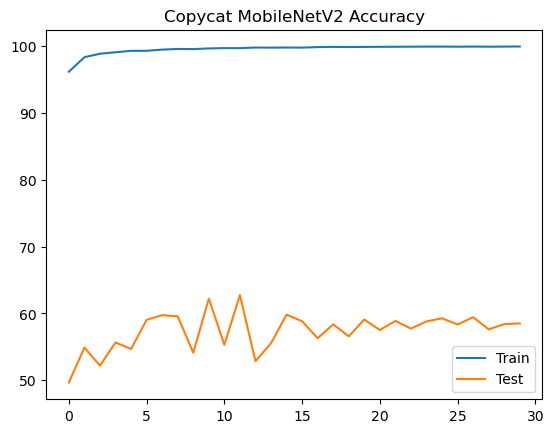

In [3]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR
import matplotlib.pyplot as plt

# PATHS
COPYCAT_DIR = "/home/student/Downloads/copycat_fer_project/npdd_sl"
TEST_DIR    = "/home/student/Downloads/copycat_fer_project/FER2013_3 Class/test"

SAVE_PATH   = "/home/student/Downloads/copycat_fer_project/copycat_mobilenetv2.pth"

# CONFIG
BATCH_SIZE = 64
EPOCHS = 30
LR = 3e-4
NUM_CLASSES = 3
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Using device:", DEVICE)

# TRANSFORMS
train_tf = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

test_tf = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

# DATASETS
train_ds = datasets.ImageFolder(COPYCAT_DIR, transform=train_tf)
test_ds  = datasets.ImageFolder(TEST_DIR, transform=test_tf)

print("Copycat Classes:", train_ds.classes)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

# MODEL (SAME AS TARGET)
model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)

model.classifier = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(model.last_channel, NUM_CLASSES)
)

model = model.to(DEVICE)

# FREEZE FIRST HALF (Better stability)
for param in model.features[:-4].parameters():
    param.requires_grad = False

criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR,
    weight_decay=1e-4
)

scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS)

# TRAINING
train_acc_list = []
test_acc_list = []

for epoch in range(EPOCHS):

    model.train()
    correct, total, running_loss = 0, 0, 0

    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        pred = out.argmax(1)
        correct += (pred == y).sum().item()
        total += y.size(0)

    scheduler.step()

    train_acc = 100 * correct / total
    train_acc_list.append(train_acc)

    # TEST
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            out = model(x)
            pred = out.argmax(1)
            correct += (pred == y).sum().item()
            total += y.size(0)

    test_acc = 100 * correct / total
    test_acc_list.append(test_acc)

    print(f"Epoch {epoch+1}: Train={train_acc:.2f}% | Test={test_acc:.2f}%")

torch.save(model.state_dict(), SAVE_PATH)
print("Copycat model saved:", SAVE_PATH)

# PLOT
plt.plot(train_acc_list, label="Train")
plt.plot(test_acc_list, label="Test")
plt.legend()
plt.title("Copycat MobileNetV2 Accuracy")
plt.show()

Using device: cuda
Classes: ['happy', 'neutral', 'sad']
Epoch 1: Train=95.91% | Val=98.05% | Test=47.81% || TL=0.275 VL=0.221 TeL=1.546
Epoch 2: Train=98.18% | Val=98.32% | Test=47.13% || TL=0.221 VL=0.211 TeL=1.648
Epoch 3: Train=98.76% | Val=98.47% | Test=55.57% || TL=0.207 VL=0.209 TeL=1.193
Epoch 4: Train=99.11% | Val=98.37% | Test=55.85% || TL=0.198 VL=0.211 TeL=1.308
Epoch 5: Train=99.22% | Val=98.89% | Test=57.24% || TL=0.194 VL=0.200 TeL=1.193
Epoch 6: Train=99.40% | Val=98.79% | Test=56.86% || TL=0.189 VL=0.201 TeL=1.363
Epoch 7: Train=99.52% | Val=98.96% | Test=57.15% || TL=0.187 VL=0.199 TeL=1.241
Epoch 8: Train=99.51% | Val=98.74% | Test=55.31% || TL=0.186 VL=0.200 TeL=1.392
Epoch 9: Train=99.56% | Val=98.86% | Test=56.84% || TL=0.184 VL=0.197 TeL=1.214
Epoch 10: Train=99.69% | Val=98.72% | Test=58.30% || TL=0.182 VL=0.199 TeL=1.210
Epoch 11: Train=99.75% | Val=98.76% | Test=57.57% || TL=0.180 VL=0.201 TeL=1.192
Epoch 12: Train=99.72% | Val=98.71% | Test=59.12% || TL=0.180 

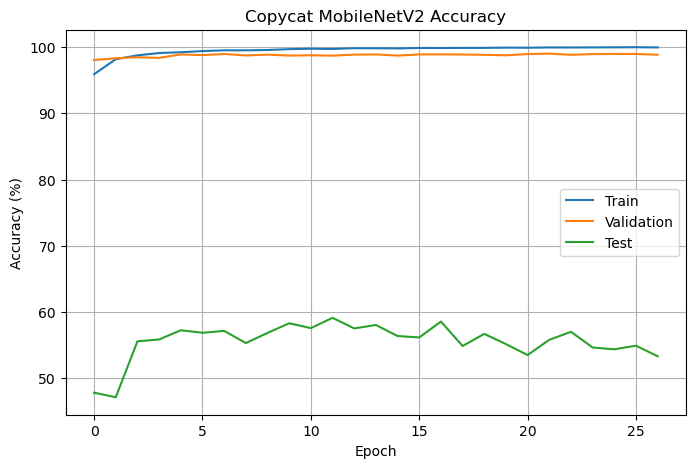

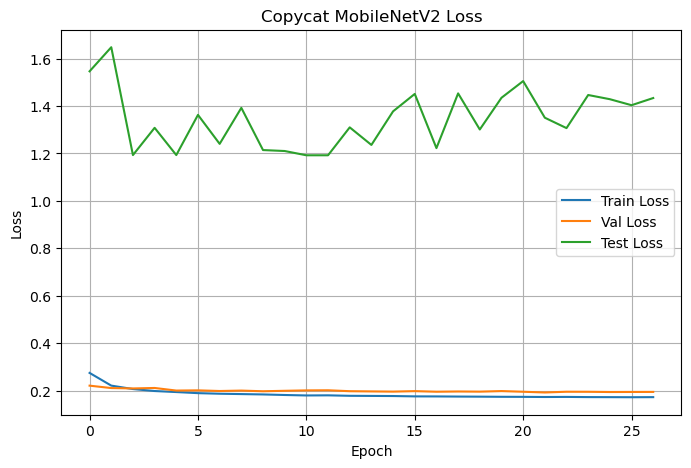

In [4]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
from torch.optim.lr_scheduler import CosineAnnealingLR
import matplotlib.pyplot as plt

# PATHS
COPYCAT_DIR = "/home/student/Downloads/copycat_fer_project/npdd_sl"
TEST_DIR    = "/home/student/Downloads/copycat_fer_project/FER2013_3 Class/test"

SAVE_PATH   = "/home/student/Downloads/copycat_fer_project/copycat_mobilenetv2.pth"

# CONFIG
BATCH_SIZE = 64
EPOCHS = 30
LR = 3e-4
NUM_CLASSES = 3
PATIENCE = 5
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Using device:", DEVICE)

# TRANSFORMS
train_tf = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

test_tf = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

# DATASET
full_train = datasets.ImageFolder(COPYCAT_DIR, transform=train_tf)
test_ds  = datasets.ImageFolder(TEST_DIR, transform=test_tf)

# VALIDATION SPLIT
val_size = int(0.2 * len(full_train))
train_size = len(full_train) - val_size
train_ds, val_ds = random_split(full_train, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

print("Classes:", full_train.classes)

# MODEL (SAME LOGIC)
model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)

model.classifier = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(model.last_channel, NUM_CLASSES)
)

model = model.to(DEVICE)

for param in model.features[:-4].parameters():
    param.requires_grad = False

criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR,
    weight_decay=1e-4
)

scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS)

# EARLY STOPPING
best_val_loss = float("inf")
counter = 0

# METRICS STORAGE
train_acc_list, val_acc_list, test_acc_list = [], [], []
train_loss_list, val_loss_list, test_loss_list = [], [], []

# TRAINING LOOP
for epoch in range(EPOCHS):

    # TRAIN
    model.train()
    correct, total, running_loss = 0, 0, 0

    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        pred = out.argmax(1)
        correct += (pred == y).sum().item()
        total += y.size(0)

    scheduler.step()

    train_acc = 100 * correct / total
    train_loss = running_loss / len(train_loader)

    #VALIDATION 
    model.eval()
    correct, total, val_loss = 0, 0, 0

    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            out = model(x)
            loss = criterion(out, y)

            val_loss += loss.item()
            pred = out.argmax(1)
            correct += (pred == y).sum().item()
            total += y.size(0)

    val_acc = 100 * correct / total
    val_loss /= len(val_loader)

    # TEST 
    correct, total, test_loss = 0, 0, 0

    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            out = model(x)
            loss = criterion(out, y)

            test_loss += loss.item()
            pred = out.argmax(1)
            correct += (pred == y).sum().item()
            total += y.size(0)

    test_acc = 100 * correct / total
    test_loss /= len(test_loader)

    # STORE METRICS
    train_acc_list.append(train_acc)
    val_acc_list.append(val_acc)
    test_acc_list.append(test_acc)

    train_loss_list.append(train_loss)
    val_loss_list.append(val_loss)
    test_loss_list.append(test_loss)

    print(f"Epoch {epoch+1}: "
          f"Train={train_acc:.2f}% | Val={val_acc:.2f}% | Test={test_acc:.2f}% || "
          f"TL={train_loss:.3f} VL={val_loss:.3f} TeL={test_loss:.3f}")

    # EARLY STOPPING CHECK
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), SAVE_PATH)
    else:
        counter += 1
        if counter >= PATIENCE:
            print("Early stopping triggered")
            break

print("Best model saved:", SAVE_PATH)

#ACCURACY GRAPH
plt.figure(figsize=(8,5))
plt.plot(train_acc_list, label="Train")
plt.plot(val_acc_list, label="Validation")
plt.plot(test_acc_list, label="Test")
plt.legend()
plt.title("Copycat MobileNetV2 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.grid(True)
plt.show()

#LOSS GRAPH 
plt.figure(figsize=(8,5))
plt.plot(train_loss_list, label="Train Loss")
plt.plot(val_loss_list, label="Val Loss")
plt.plot(test_loss_list, label="Test Loss")
plt.legend()
plt.title("Copycat MobileNetV2 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import itertools
from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix

# CONFIG 
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
NUM_CLASSES = 3
SAVE_PATH = "/home/student/Downloads/copycat_fer_project/copycat_mobilenetv2.pth"
TEST_DIR = "/home/student/Downloads/copycat_fer_project/FER2013_3 Class/test"

# TRANSFORM 
test_tf = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

test_ds = datasets.ImageFolder(TEST_DIR, transform=test_tf)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

class_names = test_ds.classes

# RECREATE MODEL 
model = models.mobilenet_v2(weights=None)

model.classifier = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(model.last_channel, NUM_CLASSES)
)

model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
model = model.to(DEVICE)
model.eval()

#  GET PREDICTIONS 
all_preds = []
all_labels = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(DEVICE)
        outputs = model(x)
        preds = outputs.argmax(1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(y.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# CONFUSION MATRIX 
cm = confusion_matrix(all_labels, all_preds)

print("Confusion Matrix (Raw Counts):")
print(cm)

Confusion Matrix (Raw Counts):
[[1678   11   85]
 [ 745  128  360]
 [ 629   50  568]]


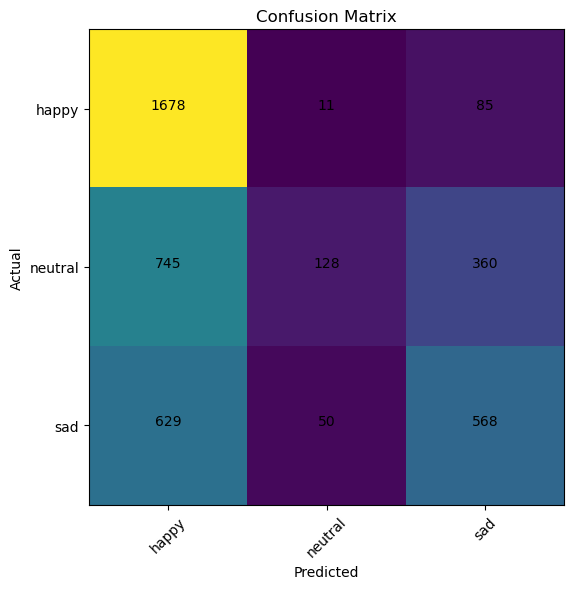

In [4]:
plt.figure(figsize=(6,6))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(np.arange(len(class_names)), class_names, rotation=45)
plt.yticks(np.arange(len(class_names)), class_names)

for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j],
             horizontalalignment="center")

plt.tight_layout()
plt.show()

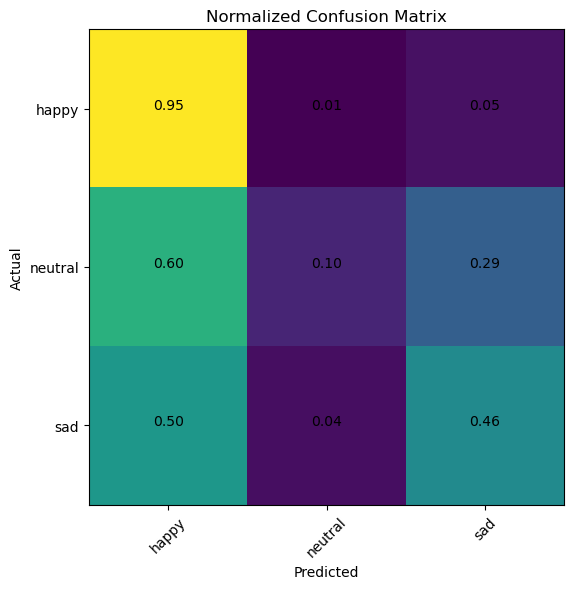

In [5]:
cm_normalized = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(6,6))
plt.imshow(cm_normalized)
plt.title("Normalized Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(np.arange(len(class_names)), class_names, rotation=45)
plt.yticks(np.arange(len(class_names)), class_names)

for i, j in itertools.product(range(cm_normalized.shape[0]), range(cm_normalized.shape[1])):
    plt.text(j, i, f"{cm_normalized[i, j]:.2f}",
             horizontalalignment="center")

plt.tight_layout()
plt.show()